# SigLIP Feature Clustering for BIM Objects

KMeans clustering on SigLIP embeddings (1024-dim) from rendered views.
Compare **colored** vs **colorless** renders, with PCA reduction and handcrafted feature fusion.

All evaluation uses **19 merged types**.

In [1]:
import sys, json, warnings
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import trimesh
from pathlib import Path
from scipy.stats import entropy
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load dataset + SigLIP features + handcrafted features
df_all = pd.read_parquet('../../processed_data/features/train_features.parquet')
with open('../../data/annotated_subset.json') as f:
    annotated = json.load(f)
annotated_gids = set(d['GlobalId'] for d in annotated)
df = df_all[df_all['GlobalId'].isin(annotated_gids)].copy().reset_index(drop=True)

colored_dir = Path('../../processed_data/rendered_features/siglip2_large_16_512/colored')
colorless_dir = Path('../../processed_data/rendered_features/siglip2_large_16_512/colorless')
mesh_dir = Path('../../processed_data/meshes/train')

def load_features(feat_dir, gids):
    features, matched_gids = [], []
    for gid in gids:
        path = feat_dir / f'{gid}.npy'
        if path.exists():
            features.append(np.load(path))
            matched_gids.append(gid)
    return np.stack(features), matched_gids

X_colored, gids_colored = load_features(colored_dir, df['GlobalId'].values)
X_colorless, gids_colorless = load_features(colorless_dir, df['GlobalId'].values)

# Keep only objects present in both
gids_both = sorted(set(gids_colored) & set(gids_colorless))
df_model = df[df['GlobalId'].isin(gids_both)].copy().reset_index(drop=True)
idx_c = {g: i for i, g in enumerate(gids_colored)}
idx_cl = {g: i for i, g in enumerate(gids_colorless)}
X_colored = np.stack([X_colored[idx_c[g]] for g in df_model['GlobalId']])
X_colorless = np.stack([X_colorless[idx_cl[g]] for g in df_model['GlobalId']])

# Compute handcrafted 9 features
BASELINE = ['Length', 'CrossSectionArea', 'Volume', 'NumVertices']
Z_AXIS = np.array([0, 0, 1])
ref_dirs = np.array(trimesh.creation.icosphere(subdivisions=1).vertices)
ref_dirs = ref_dirs / np.linalg.norm(ref_dirs, axis=1, keepdims=True)
N_BINS = len(ref_dirs)

engineered = []
for gid in df_model['GlobalId'].values:
    mesh_path = mesh_dir / f'{gid}.obj'
    if not mesh_path.exists():
        engineered.append(None); continue
    mesh = trimesh.load(mesh_path, force='mesh', process=False)
    verts = np.array(mesh.vertices)
    if len(verts) < 3:
        engineered.append(None); continue
    pca = PCA(n_components=3).fit(verts)
    pc1_z = abs(np.dot(pca.components_[0], Z_AXIS))
    pc3_z = abs(np.dot(pca.components_[2], Z_AXIS))
    extents = np.sqrt(pca.explained_variance_)
    cs_ratio = extents[2] / extents[1] if extents[1] > 1e-8 else 0.0
    normals, areas = mesh.face_normals, mesh.area_faces
    if len(normals) > 0 and len(areas) > 0:
        dots = normals @ ref_dirs.T
        hist = np.bincount(dots.argmax(axis=1), weights=areas, minlength=N_BINS)
        hist = hist / hist.sum()
        norm_ent = entropy(hist) / np.log(N_BINS)
        horiz_frac = areas[np.abs(normals @ Z_AXIS) > 0.9].sum() / areas.sum()
    else:
        norm_ent, horiz_frac = 0.0, 0.0
    engineered.append({'pc1_z': pc1_z, 'pc3_z': pc3_z, 'cs_aspect_ratio': cs_ratio,
                       'normal_entropy': norm_ent, 'horiz_frac': horiz_frac})

valid_mask = np.array([e is not None for e in engineered])
df_valid = df_model[valid_mask].reset_index(drop=True)
X_colored = X_colored[valid_mask]
X_colorless = X_colorless[valid_mask]
df_eng = pd.DataFrame([e for e in engineered if e is not None])
X_handcrafted = np.hstack([
    np.log1p(df_valid[BASELINE].clip(lower=0).values),
    df_eng[['pc1_z', 'pc3_z', 'cs_aspect_ratio', 'normal_entropy', 'horiz_frac']].values
])

# Merge types (24 → 19)
TYPE_MAP = {
    'IfcWall': 'Wall', 'IfcWallStandardCase': 'Wall',
    'IfcFurniture': 'Furniture', 'IfcFurnishingElement': 'Furniture',
    'IfcSystemFurnitureElement': 'Furniture',
    'IfcDistributionFlowElement': 'MEP', 'IfcFlowTerminal': 'MEP',
    'IfcStair': 'Stair', 'IfcStairFlight': 'Stair',
}
ifc_types = np.array([TYPE_MAP.get(t, t) for t in df_valid['IfcType'].values])

print(f'{len(df_valid)} objects, {len(set(ifc_types))} merged types')
print(f'Colored: {X_colored.shape}, Colorless: {X_colorless.shape}, Handcrafted: {X_handcrafted.shape}')

1845 objects, 19 merged types
Colored: (1845, 1024), Colorless: (1845, 1024), Handcrafted: (1845, 9)


In [3]:
SEEDS = list(range(42, 52))
PCA_DIMS = [2, 4, 8, 16, 32]
K_VALUES = [4, 8, 16, 24, 32]

def compute_purity(labels, true_labels):
    return sum(pd.Series(true_labels[labels == c]).value_counts().iloc[0]
               for c in np.unique(labels)) / len(labels)

def eval_kmeans(X, labels, k=24, seeds=SEEDS, scale=True):
    if scale:
        X = RobustScaler().fit_transform(X)
    metrics = {'purity': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}
    for s in seeds:
        lab = MiniBatchKMeans(k, batch_size=1024, n_init='auto', random_state=s).fit_predict(X)
        metrics['purity'].append(compute_purity(lab, labels))
        metrics['silhouette'].append(silhouette_score(X, lab))
        metrics['davies_bouldin'].append(davies_bouldin_score(X, lab))
        metrics['calinski_harabasz'].append(calinski_harabasz_score(X, lab))
    return {k_: (np.mean(v), np.std(v)) for k_, v in metrics.items()}

def per_type_purity(lab, true_labels):
    cluster_dominant = {}
    for c in np.unique(lab):
        mask = lab == c
        counts = pd.Series(true_labels[mask]).value_counts()
        cluster_dominant[c] = counts.index[0]
    type_purity = {}
    for t in np.unique(true_labels):
        t_mask = true_labels == t
        t_objects = t_mask.sum()
        correct = sum(1 for i in np.where(t_mask)[0] if cluster_dominant[lab[i]] == t)
        type_purity[t] = correct / t_objects
    return type_purity

def title_metrics(X, lab, labels):
    p = compute_purity(lab, labels)
    s = silhouette_score(X, lab)
    db = davies_bouldin_score(X, lab)
    return f'Purity={p:.3f}  Sil={s:.3f}  DB={db:.2f}'

# Precompute PCA projections
pca_colored, pca_colorless = {}, {}
for d in PCA_DIMS:
    pca_colored[d] = PCA(n_components=d, random_state=42).fit_transform(X_colored)
    pca_colorless[d] = PCA(n_components=d, random_state=42).fit_transform(X_colorless)
pca_colored[1024] = X_colored
pca_colorless[1024] = X_colorless
all_dims = PCA_DIMS + [1024]

print('Ready. PCA variance retained (colored):')
for d in PCA_DIMS:
    pca_obj = PCA(n_components=d, random_state=42).fit(X_colored)
    print(f'  PCA-{d}: {pca_obj.explained_variance_ratio_.sum():.1%}')

Ready. PCA variance retained (colored):
  PCA-2: 38.1%
  PCA-4: 50.5%
  PCA-8: 63.7%
  PCA-16: 74.9%
  PCA-32: 84.7%


## 1. PCA × k Purity Grid (SigLIP only)

In [4]:
# Sweep PCA dims × k for colored, colorless, and handcrafted baseline
dim_labels = [str(d) for d in all_dims]

grid_colored = np.zeros((len(all_dims), len(K_VALUES)))
grid_colorless = np.zeros((len(all_dims), len(K_VALUES)))
for i, d in enumerate(all_dims):
    for j, k in enumerate(K_VALUES):
        grid_colored[i, j] = eval_kmeans(pca_colored[d], ifc_types, k=k)['purity'][0]
        grid_colorless[i, j] = eval_kmeans(pca_colorless[d], ifc_types, k=k)['purity'][0]
        print(f'  PCA-{d:>4} k={k:>2}  col={grid_colored[i,j]:.3f}  cl={grid_colorless[i,j]:.3f}')

hc_purity = {k: eval_kmeans(X_handcrafted, ifc_types, k=k)['purity'][0] for k in K_VALUES}
print(f'\nHandcrafted: {" ".join(f"k={k}:{v:.3f}" for k,v in hc_purity.items())}')

  PCA-   2 k= 4  col=0.286  cl=0.274
  PCA-   2 k= 8  col=0.314  cl=0.310
  PCA-   2 k=16  col=0.356  cl=0.367
  PCA-   2 k=24  col=0.395  cl=0.406
  PCA-   2 k=32  col=0.421  cl=0.429
  PCA-   4 k= 4  col=0.301  cl=0.313
  PCA-   4 k= 8  col=0.367  cl=0.379
  PCA-   4 k=16  col=0.444  cl=0.454
  PCA-   4 k=24  col=0.470  cl=0.482
  PCA-   4 k=32  col=0.489  cl=0.503
  PCA-   8 k= 4  col=0.277  cl=0.259
  PCA-   8 k= 8  col=0.361  cl=0.374
  PCA-   8 k=16  col=0.469  cl=0.483
  PCA-   8 k=24  col=0.527  cl=0.538
  PCA-   8 k=32  col=0.557  cl=0.571
  PCA-  16 k= 4  col=0.243  cl=0.249
  PCA-  16 k= 8  col=0.352  cl=0.367
  PCA-  16 k=16  col=0.494  cl=0.497
  PCA-  16 k=24  col=0.562  cl=0.563
  PCA-  16 k=32  col=0.599  cl=0.596
  PCA-  32 k= 4  col=0.222  cl=0.221
  PCA-  32 k= 8  col=0.304  cl=0.312
  PCA-  32 k=16  col=0.431  cl=0.461
  PCA-  32 k=24  col=0.531  cl=0.533
  PCA-  32 k=32  col=0.606  cl=0.584
  PCA-1024 k= 4  col=0.301  cl=0.307
  PCA-1024 k= 8  col=0.384  cl=0.410
 

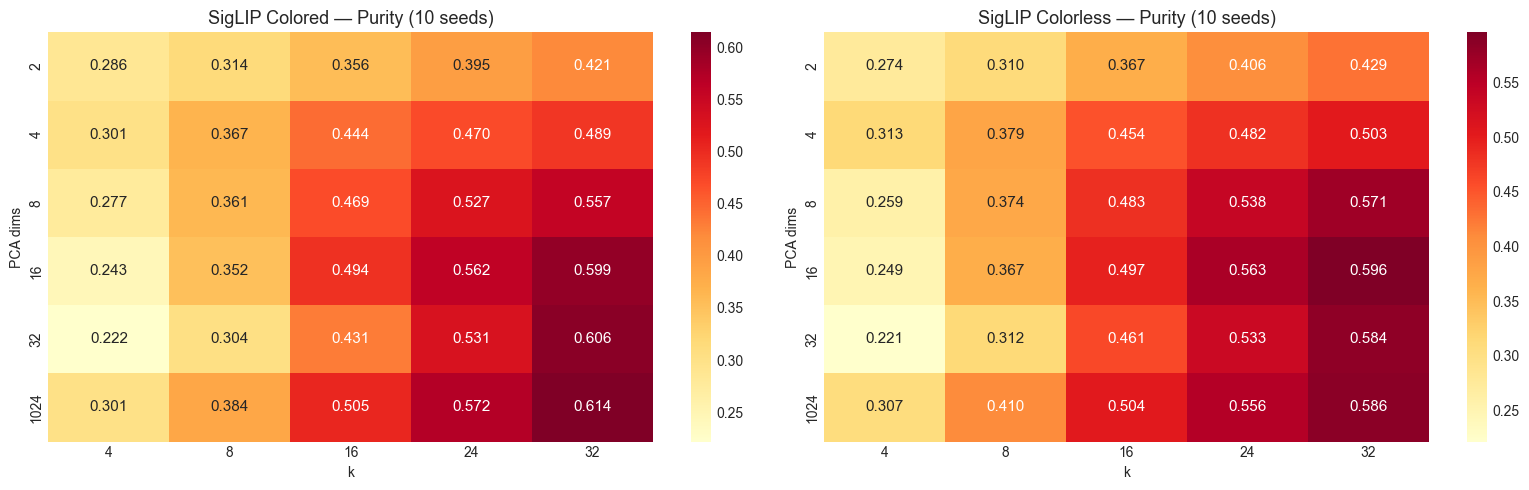

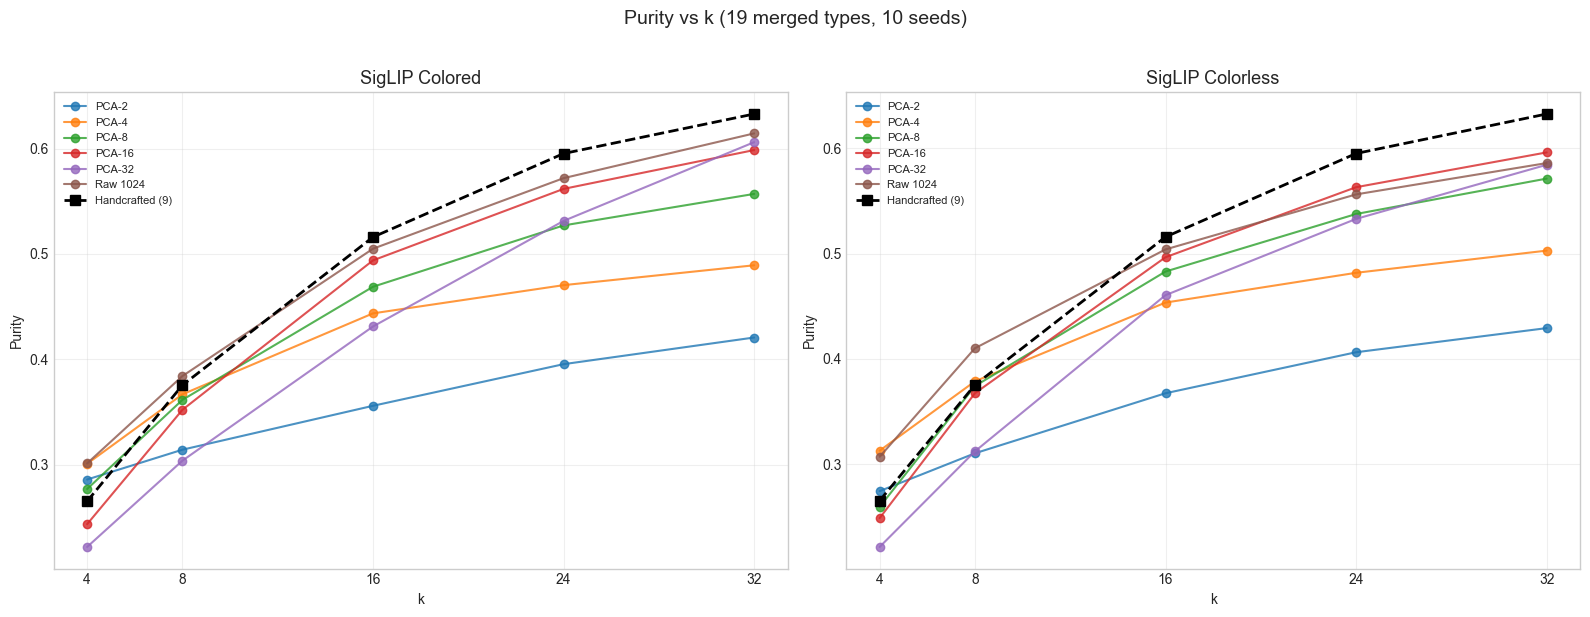

In [5]:
# Heatmaps: PCA × k
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, grid, title in [(axes[0], grid_colored, 'Colored'), (axes[1], grid_colorless, 'Colorless')]:
    sns.heatmap(grid, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=[str(k) for k in K_VALUES], yticklabels=dim_labels,
                ax=ax, annot_kws={'size': 11})
    ax.set_xlabel('k'); ax.set_ylabel('PCA dims')
    ax.set_title(f'SigLIP {title} — Purity (10 seeds)', fontsize=13)
plt.tight_layout(); plt.show()

# Line plot: purity vs k
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, grid, title in [(axes[0], grid_colored, 'Colored'), (axes[1], grid_colorless, 'Colorless')]:
    for i, d in enumerate(all_dims):
        label = f'PCA-{d}' if d != 1024 else 'Raw 1024'
        ax.plot(K_VALUES, grid[i], 'o-', label=label, alpha=0.8)
    ax.plot(K_VALUES, [hc_purity[k] for k in K_VALUES], 's--', color='black',
            linewidth=2, markersize=7, label='Handcrafted (9)')
    ax.set_xlabel('k'); ax.set_ylabel('Purity')
    ax.set_title(f'SigLIP {title}', fontsize=13)
    ax.legend(fontsize=8); ax.set_xticks(K_VALUES); ax.grid(True, alpha=0.3)
plt.suptitle('Purity vs k (19 merged types, 10 seeds)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 2. Best PCA Config — Cluster–Type Heatmaps

Colored: best PCA-1024, k=32 → purity=0.614


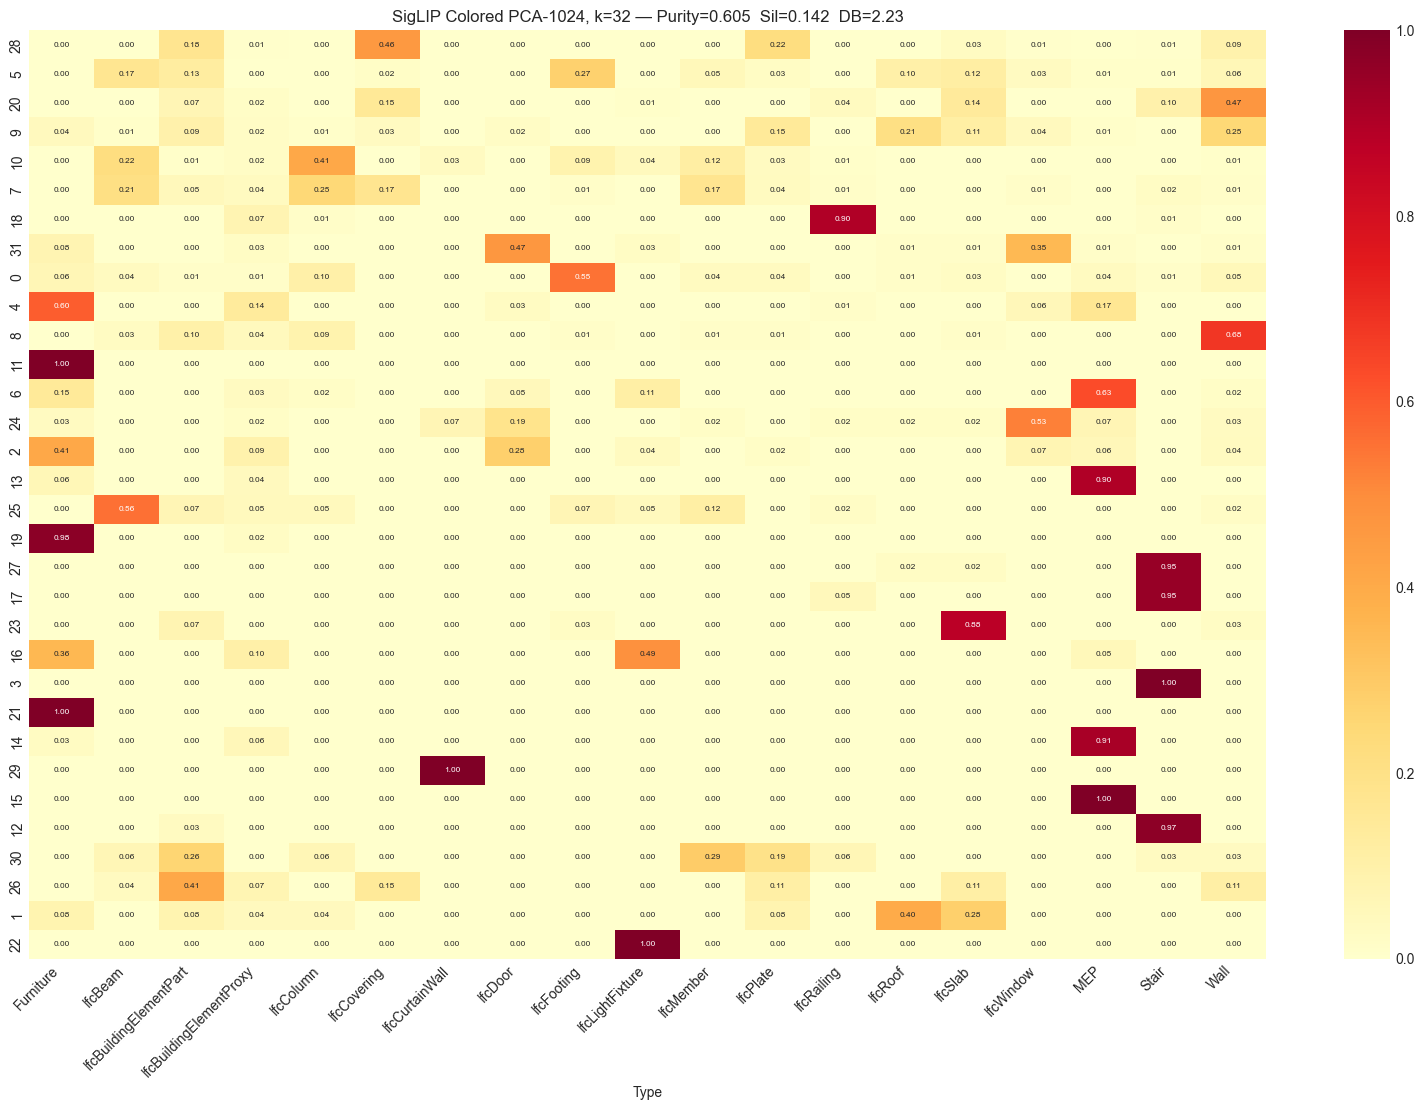

Colorless: best PCA-16, k=32 → purity=0.596


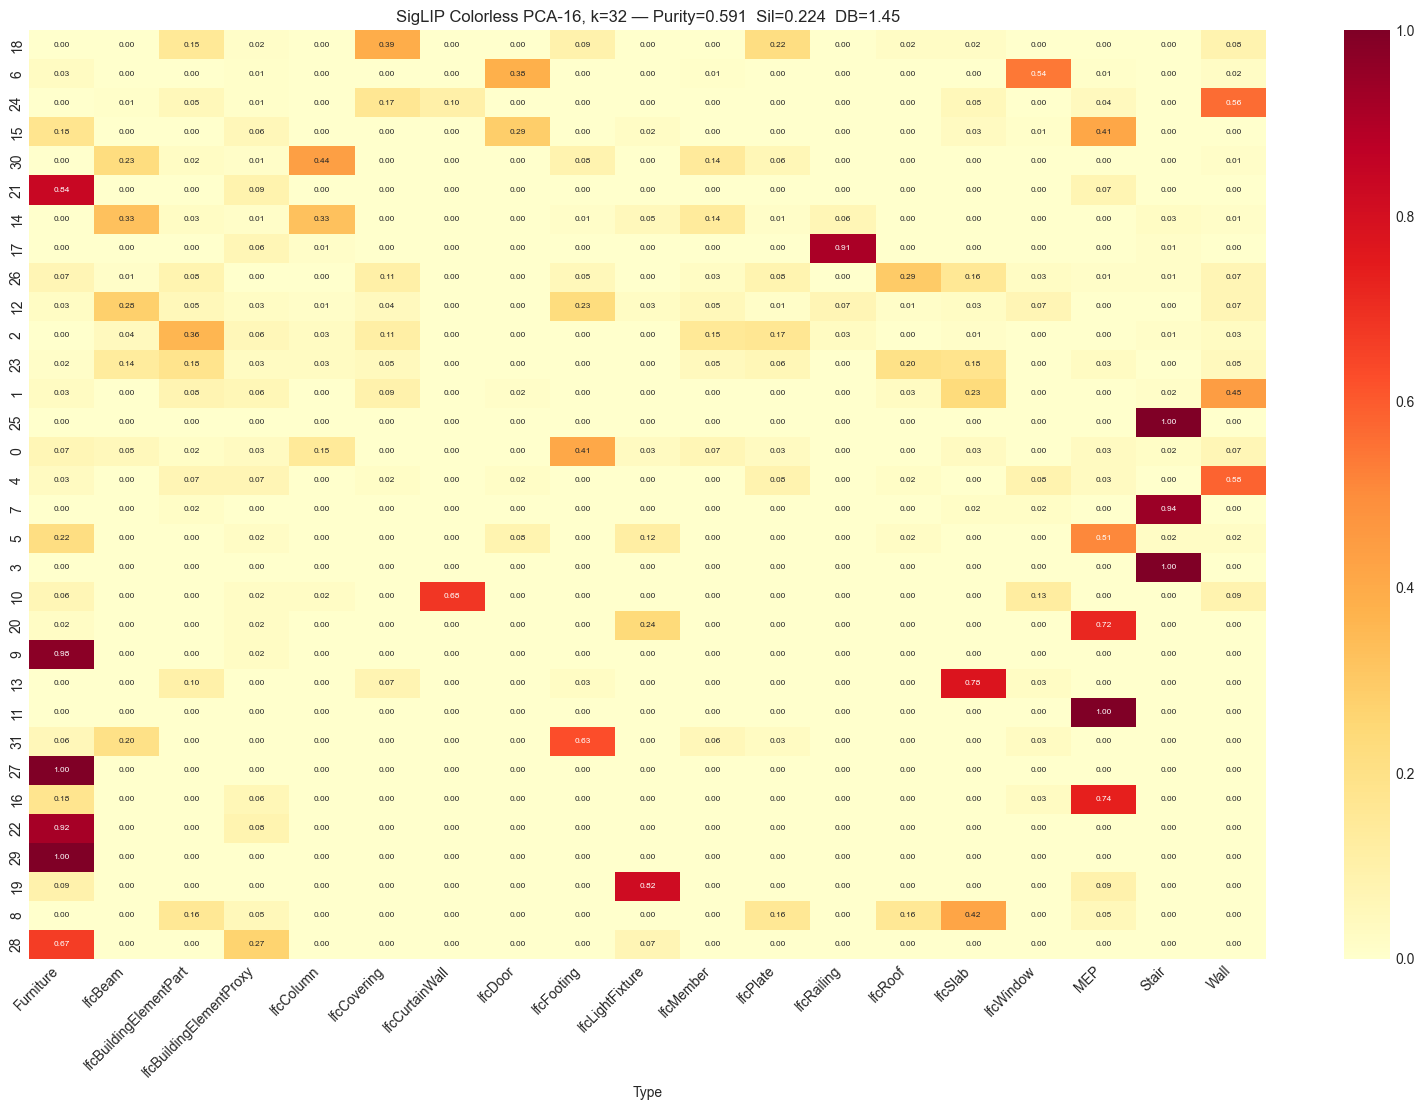

In [6]:
# Best (dim, k) per variant — heatmaps
for grid, pca_dict, label in [
    (grid_colored, pca_colored, 'Colored'),
    (grid_colorless, pca_colorless, 'Colorless'),
]:
    best_idx = np.unravel_index(grid.argmax(), grid.shape)
    best_dim, best_k = all_dims[best_idx[0]], K_VALUES[best_idx[1]]
    print(f'{label}: best PCA-{best_dim}, k={best_k} → purity={grid[best_idx]:.3f}')

    X_sc = RobustScaler().fit_transform(pca_dict[best_dim])
    lab = MiniBatchKMeans(best_k, batch_size=1024, n_init='auto', random_state=42).fit_predict(X_sc)
    ct = pd.crosstab(pd.Series(lab, name='Cluster'),
                     pd.Series(ifc_types, name='Type'), normalize='index')
    ct = ct.reindex(pd.Series(lab).value_counts().index)

    fig, ax = plt.subplots(figsize=(16, max(8, best_k * 0.35)))
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, annot_kws={'size': 6})
    ax.set_title(f'SigLIP {label} PCA-{best_dim}, k={best_k} — {title_metrics(X_sc, lab, ifc_types)}', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout(); plt.show()

## 3. SigLIP PCA + Handcrafted Fusion — All Combos

In [7]:
# PCA × k grid for SigLIP + Handcrafted fusion
grid_col_hc = np.zeros((len(all_dims), len(K_VALUES)))
grid_cl_hc = np.zeros((len(all_dims), len(K_VALUES)))
for i, d in enumerate(all_dims):
    X_fused_c = np.hstack([pca_colored[d], X_handcrafted])
    X_fused_cl = np.hstack([pca_colorless[d], X_handcrafted])
    for j, k in enumerate(K_VALUES):
        grid_col_hc[i, j] = eval_kmeans(X_fused_c, ifc_types, k=k)['purity'][0]
        grid_cl_hc[i, j] = eval_kmeans(X_fused_cl, ifc_types, k=k)['purity'][0]
        print(f'  PCA-{d:>4}+HC k={k:>2}  col={grid_col_hc[i,j]:.3f}  cl={grid_cl_hc[i,j]:.3f}')

  PCA-   2+HC k= 4  col=0.297  cl=0.284
  PCA-   2+HC k= 8  col=0.395  cl=0.389
  PCA-   2+HC k=16  col=0.542  cl=0.537
  PCA-   2+HC k=24  col=0.599  cl=0.601
  PCA-   2+HC k=32  col=0.637  cl=0.646
  PCA-   4+HC k= 4  col=0.285  cl=0.292
  PCA-   4+HC k= 8  col=0.402  cl=0.412
  PCA-   4+HC k=16  col=0.544  cl=0.551
  PCA-   4+HC k=24  col=0.623  cl=0.620
  PCA-   4+HC k=32  col=0.652  cl=0.656
  PCA-   8+HC k= 4  col=0.282  cl=0.279
  PCA-   8+HC k= 8  col=0.400  cl=0.410
  PCA-   8+HC k=16  col=0.534  cl=0.561
  PCA-   8+HC k=24  col=0.608  cl=0.623
  PCA-   8+HC k=32  col=0.662  cl=0.652
  PCA-  16+HC k= 4  col=0.273  cl=0.278
  PCA-  16+HC k= 8  col=0.394  cl=0.399
  PCA-  16+HC k=16  col=0.530  cl=0.545
  PCA-  16+HC k=24  col=0.616  cl=0.629
  PCA-  16+HC k=32  col=0.677  cl=0.654
  PCA-  32+HC k= 4  col=0.258  cl=0.258
  PCA-  32+HC k= 8  col=0.341  cl=0.360
  PCA-  32+HC k=16  col=0.496  cl=0.506
  PCA-  32+HC k=24  col=0.604  cl=0.578
  PCA-  32+HC k=32  col=0.668  cl=0.612


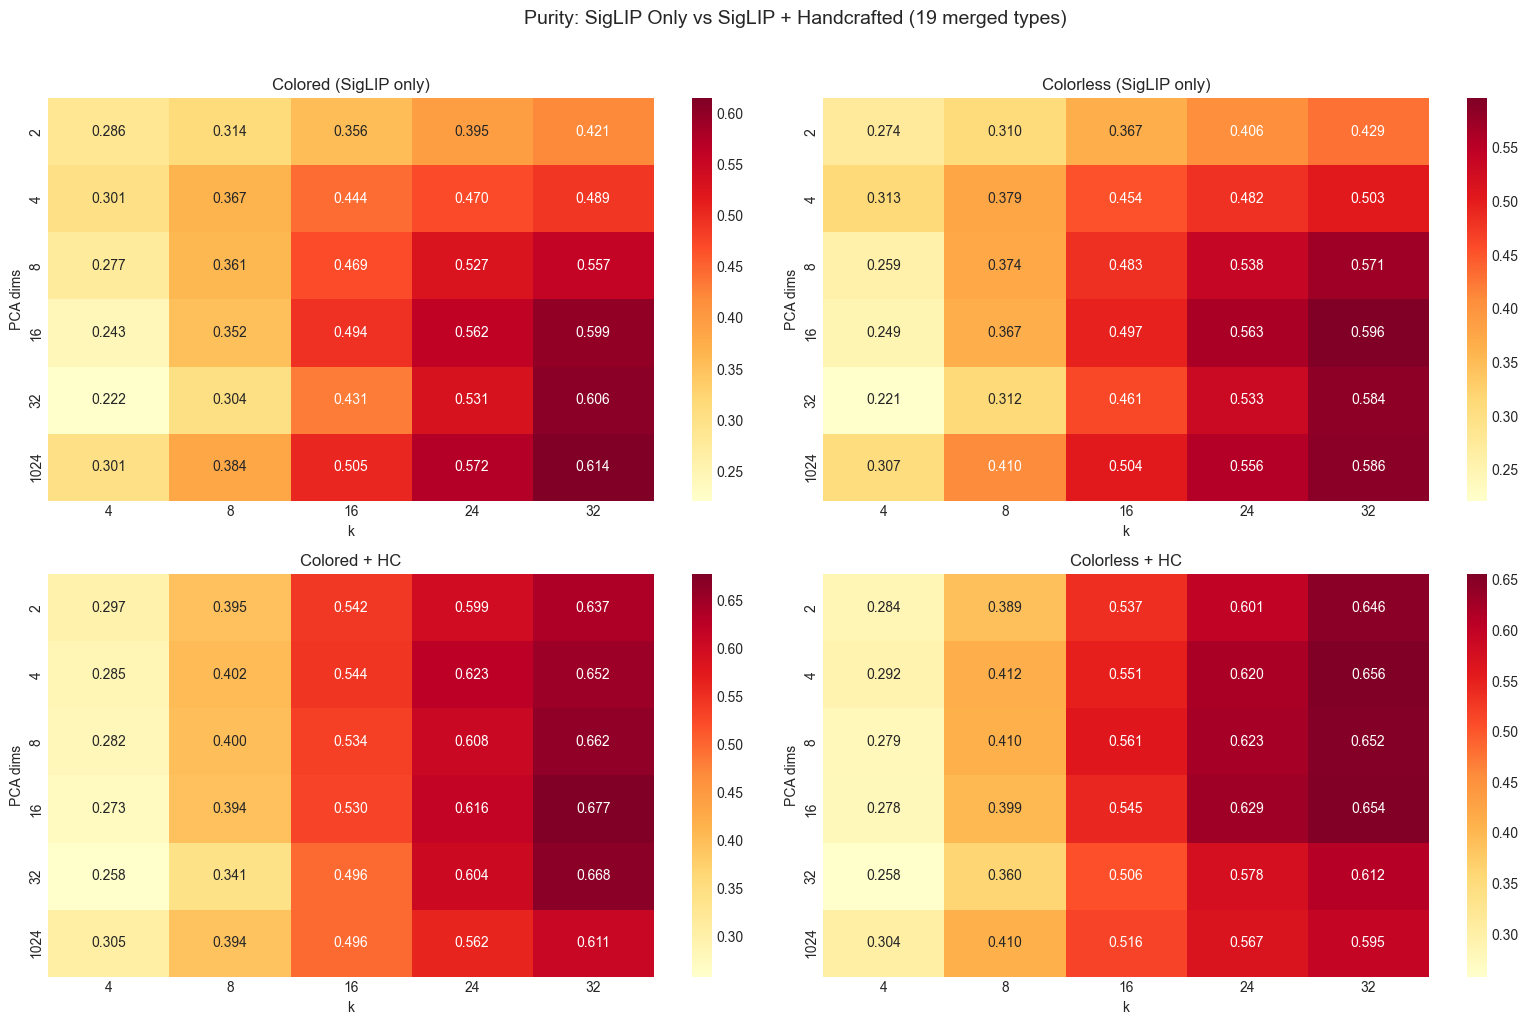

In [8]:
# Heatmaps: SigLIP-only vs SigLIP+HC (4 panels)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
grids = [(grid_colored, 'Colored (SigLIP only)'), (grid_colorless, 'Colorless (SigLIP only)'),
         (grid_col_hc, 'Colored + HC'), (grid_cl_hc, 'Colorless + HC')]
for ax, (grid, title) in zip(axes.flat, grids):
    sns.heatmap(grid, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=[str(k) for k in K_VALUES], yticklabels=dim_labels,
                ax=ax, annot_kws={'size': 10})
    ax.set_xlabel('k'); ax.set_ylabel('PCA dims')
    ax.set_title(title, fontsize=12)
plt.suptitle('Purity: SigLIP Only vs SigLIP + Handcrafted (19 merged types)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

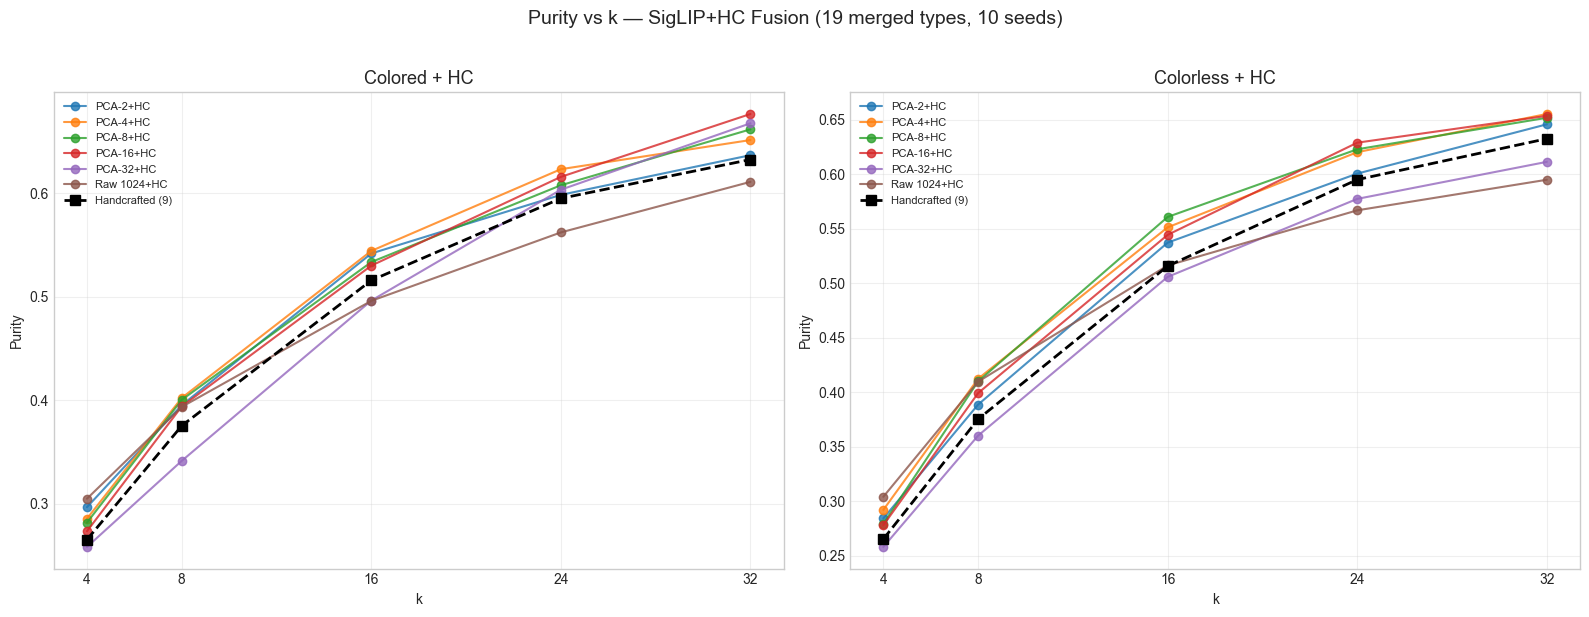

In [9]:
# Line plots: SigLIP+HC fusion vs handcrafted baseline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, grid, title in [(axes[0], grid_col_hc, 'Colored + HC'), (axes[1], grid_cl_hc, 'Colorless + HC')]:
    for i, d in enumerate(all_dims):
        label = f'PCA-{d}+HC' if d != 1024 else 'Raw 1024+HC'
        ax.plot(K_VALUES, grid[i], 'o-', label=label, alpha=0.8)
    ax.plot(K_VALUES, [hc_purity[k] for k in K_VALUES], 's--', color='black',
            linewidth=2, markersize=7, label='Handcrafted (9)')
    ax.set_xlabel('k'); ax.set_ylabel('Purity')
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=8); ax.set_xticks(K_VALUES); ax.grid(True, alpha=0.3)
plt.suptitle('Purity vs k — SigLIP+HC Fusion (19 merged types, 10 seeds)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 4. Best Overall Config — Detailed Analysis

In [10]:
# Find global best across all 4 grids
all_grids = [
    (grid_colored, pca_colored, 'Colored', False),
    (grid_colorless, pca_colorless, 'Colorless', False),
    (grid_col_hc, pca_colored, 'Colored+HC', True),
    (grid_cl_hc, pca_colorless, 'Colorless+HC', True),
]
# Also handcrafted standalone
best_hc_k = max(hc_purity, key=hc_purity.get)
print(f'Handcrafted best: k={best_hc_k} → purity={hc_purity[best_hc_k]:.3f}\n')

best_configs = []
for grid, pca_dict, label, fused in all_grids:
    idx = np.unravel_index(grid.argmax(), grid.shape)
    d, k = all_dims[idx[0]], K_VALUES[idx[1]]
    X_feat = np.hstack([pca_dict[d], X_handcrafted]) if fused else pca_dict[d]
    best_configs.append((label, d, k, grid[idx], X_feat))
    print(f'{label}: PCA-{d}, k={k} → purity={grid[idx]:.3f} ({X_feat.shape[1]} dims)')

# Sort by purity descending
best_configs.sort(key=lambda x: x[3], reverse=True)
print(f'\nBest overall: {best_configs[0][0]} PCA-{best_configs[0][1]} k={best_configs[0][2]}')

Handcrafted best: k=32 → purity=0.633

Colored: PCA-1024, k=32 → purity=0.614 (1024 dims)
Colorless: PCA-16, k=32 → purity=0.596 (16 dims)
Colored+HC: PCA-16, k=32 → purity=0.677 (25 dims)
Colorless+HC: PCA-4, k=32 → purity=0.656 (13 dims)

Best overall: Colored+HC PCA-16 k=32


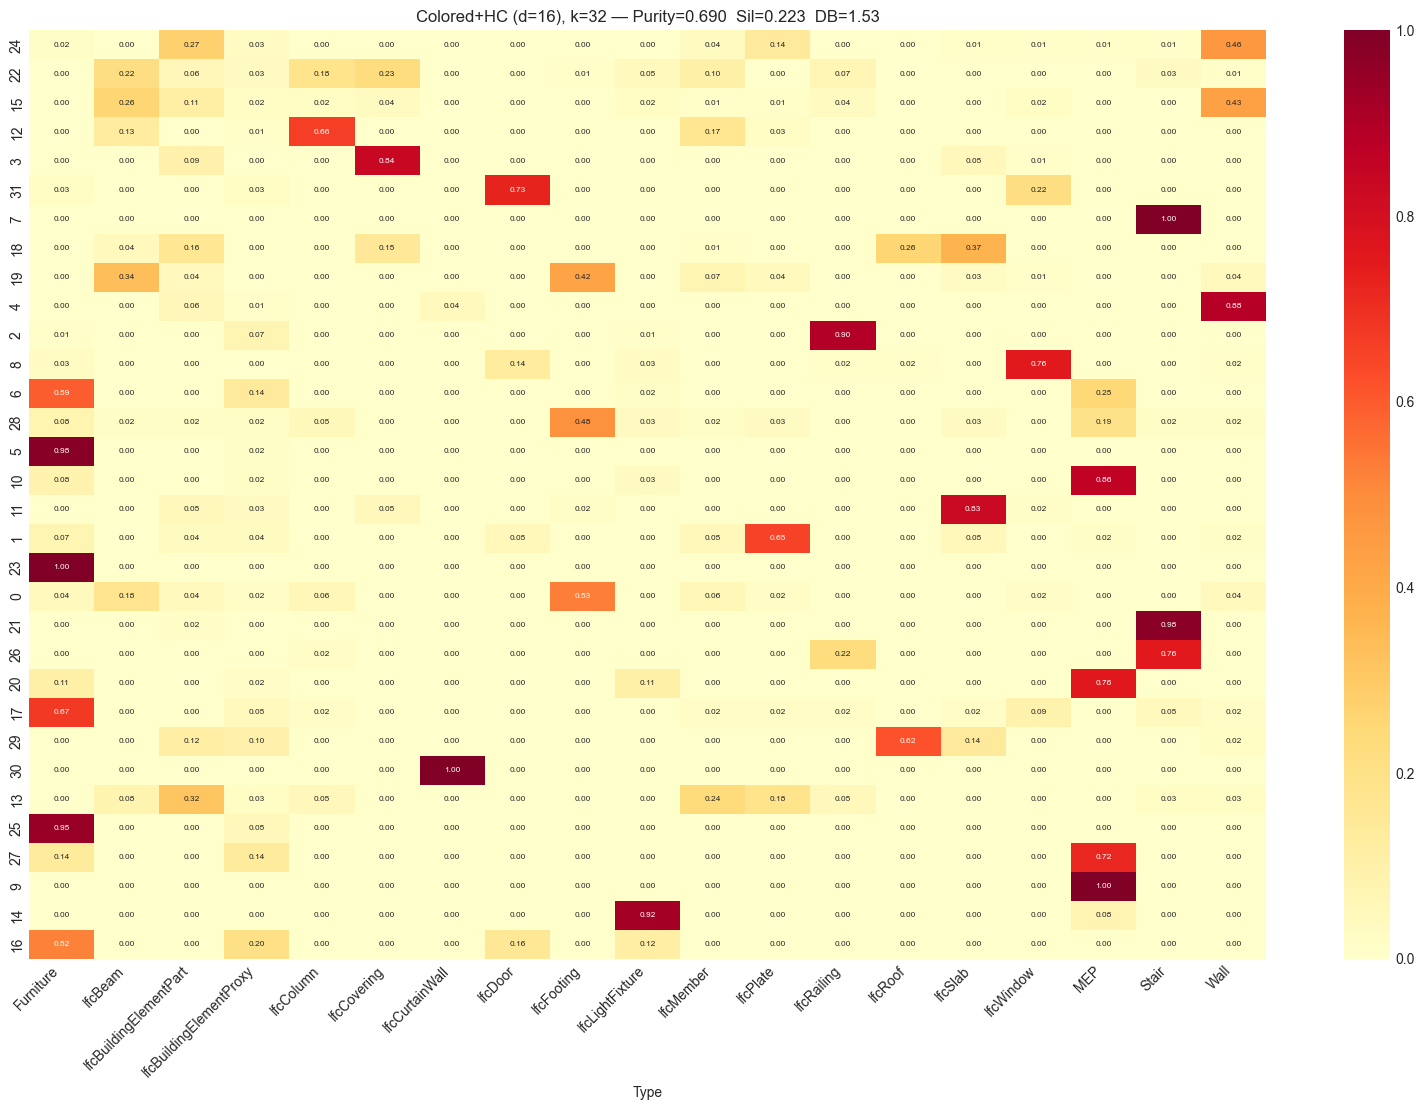

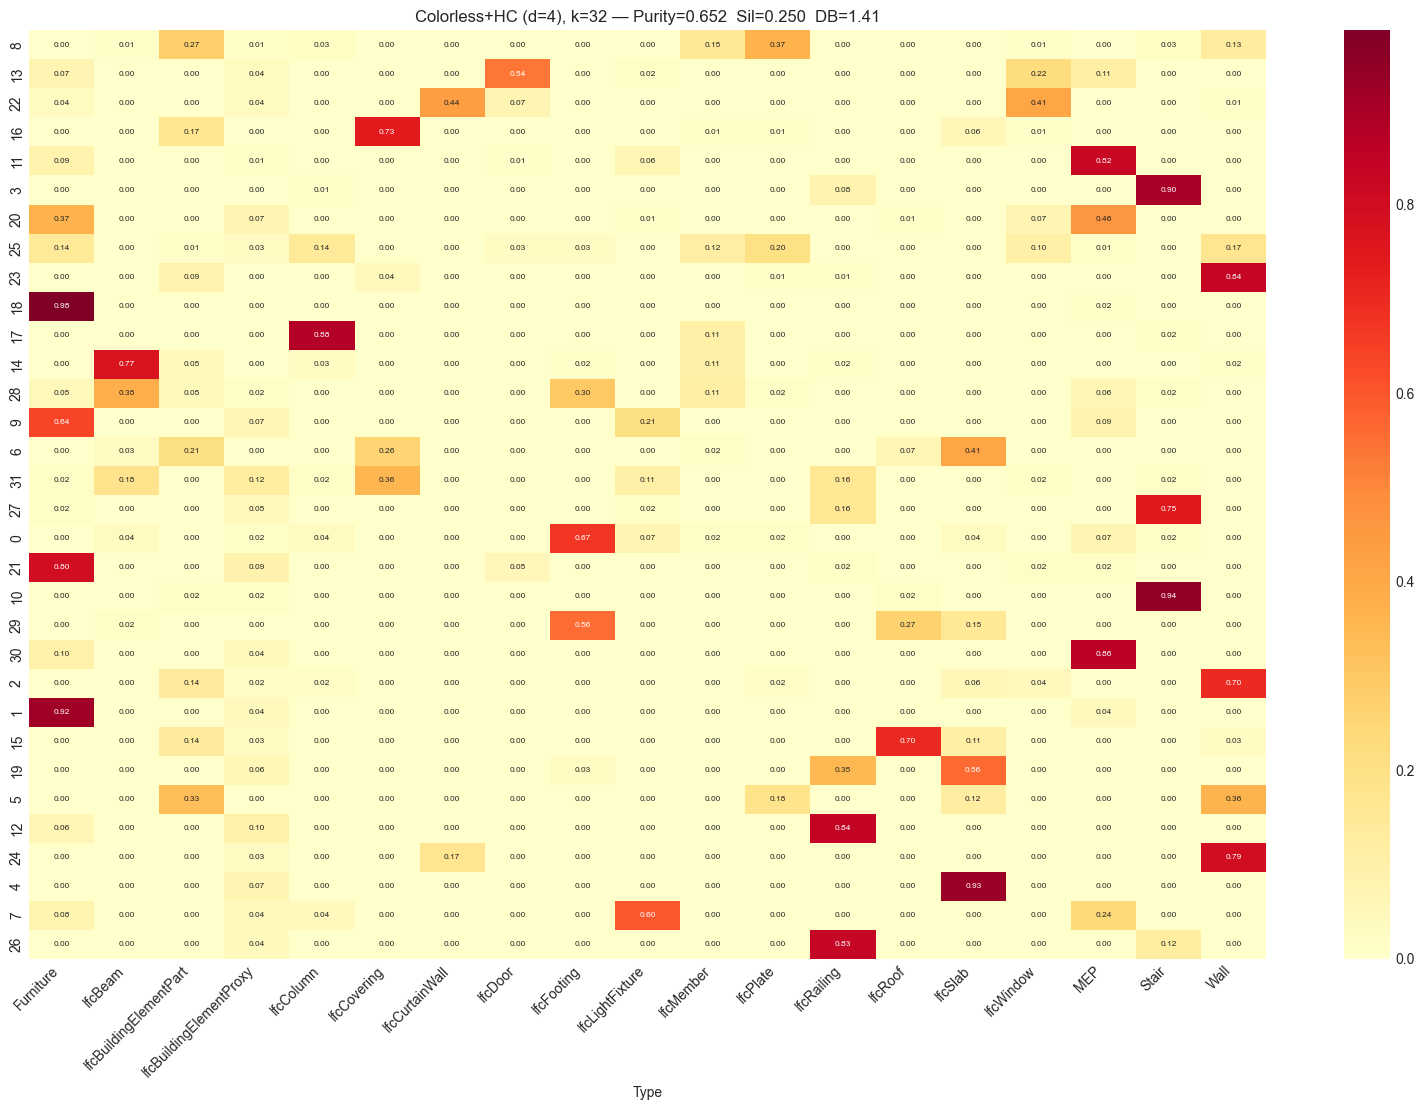

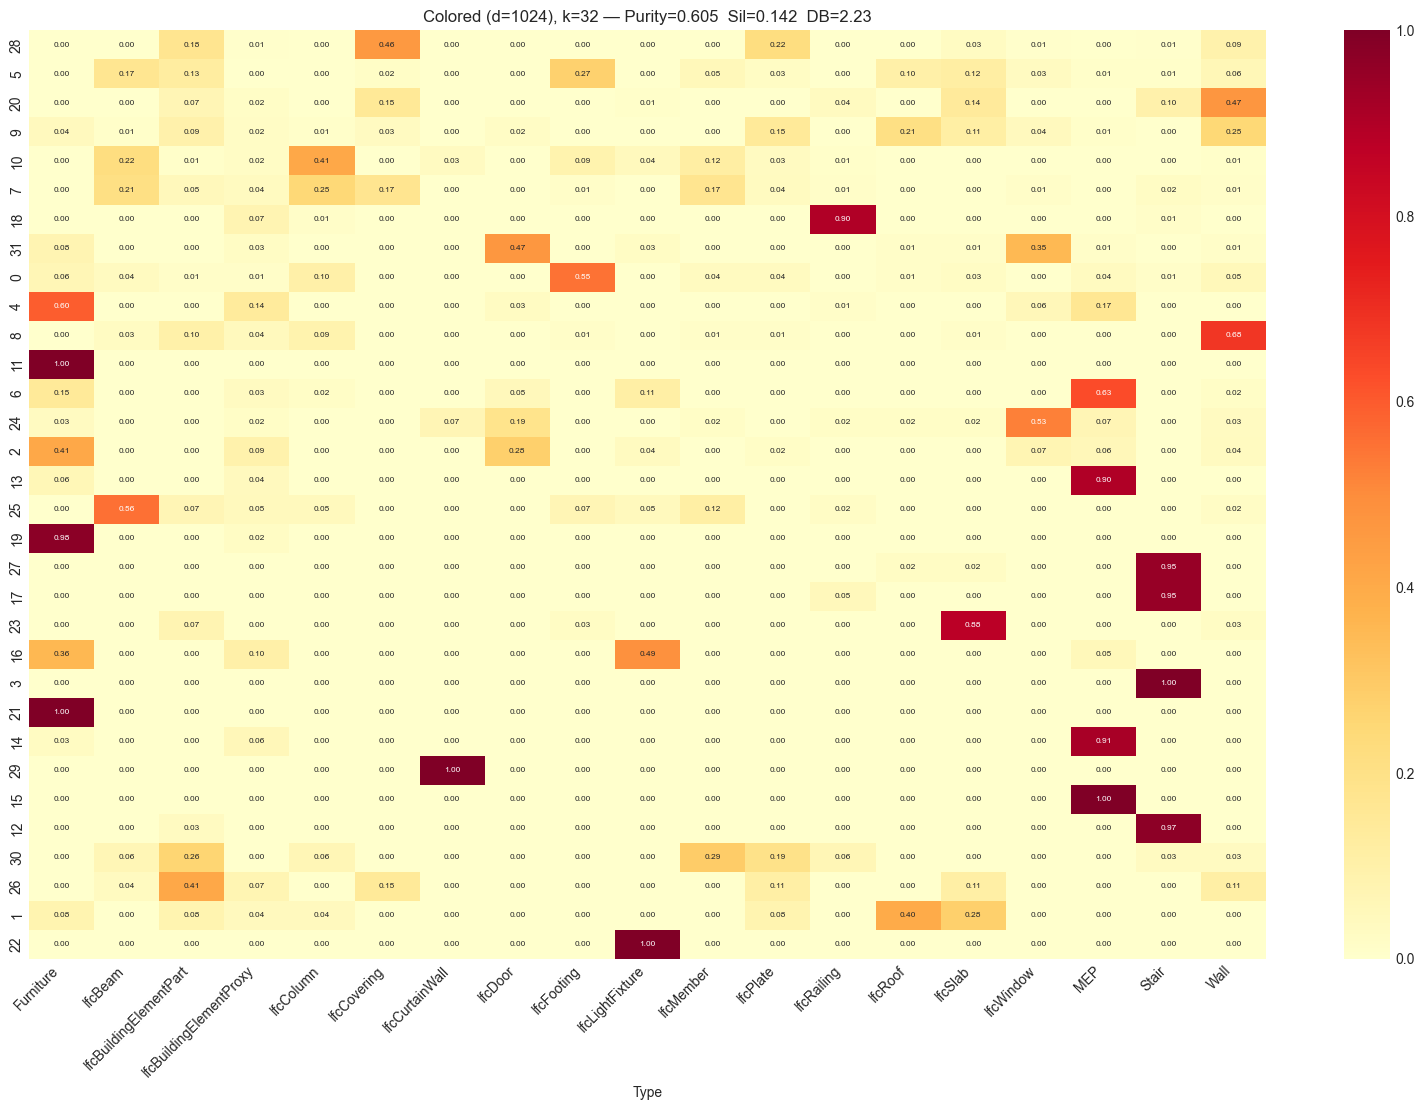

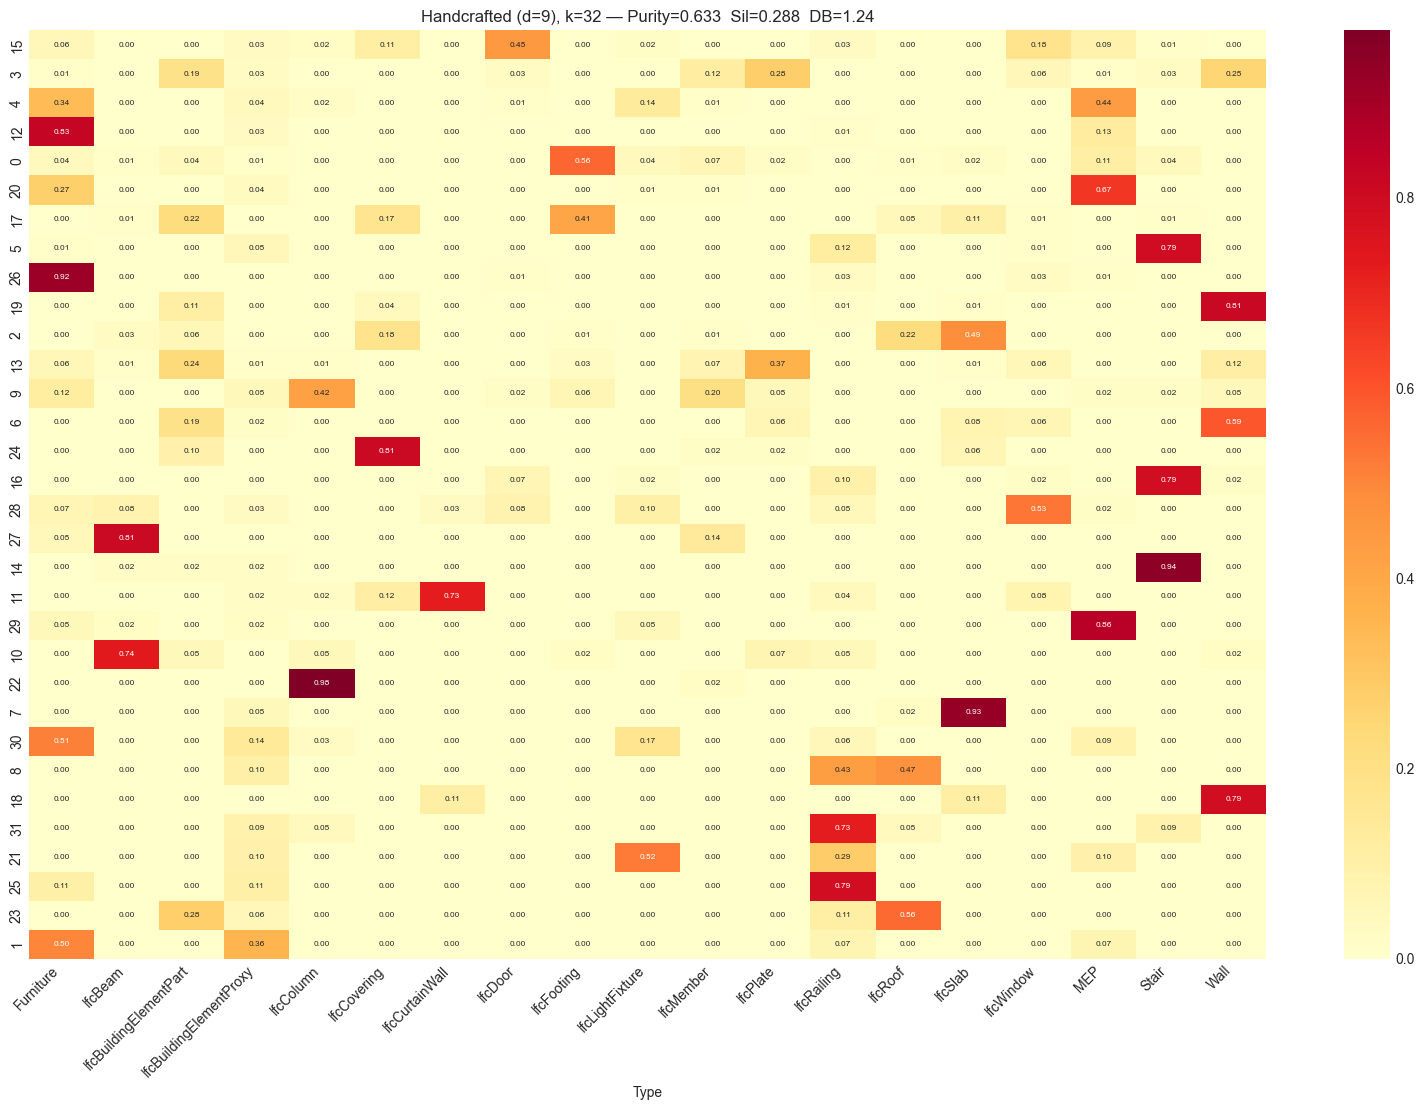

In [11]:
# Cluster–type heatmaps for top configs + handcrafted
plot_configs = best_configs[:3]  # top 3
# Add handcrafted
plot_configs.append(('Handcrafted', 9, best_hc_k, hc_purity[best_hc_k], X_handcrafted))

for label, d, k, pur, X in plot_configs:
    X_sc = RobustScaler().fit_transform(X)
    lab = MiniBatchKMeans(k, batch_size=1024, n_init='auto', random_state=42).fit_predict(X_sc)
    ct = pd.crosstab(pd.Series(lab, name='Cluster'),
                     pd.Series(ifc_types, name='Type'), normalize='index')
    ct = ct.reindex(pd.Series(lab).value_counts().index)

    fig, ax = plt.subplots(figsize=(16, max(8, k * 0.35)))
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
                annot_kws={'size': 6 if k > 24 else 7})
    ax.set_title(f'{label} (d={d}), k={k} — {title_metrics(X_sc, lab, ifc_types)}', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout(); plt.show()

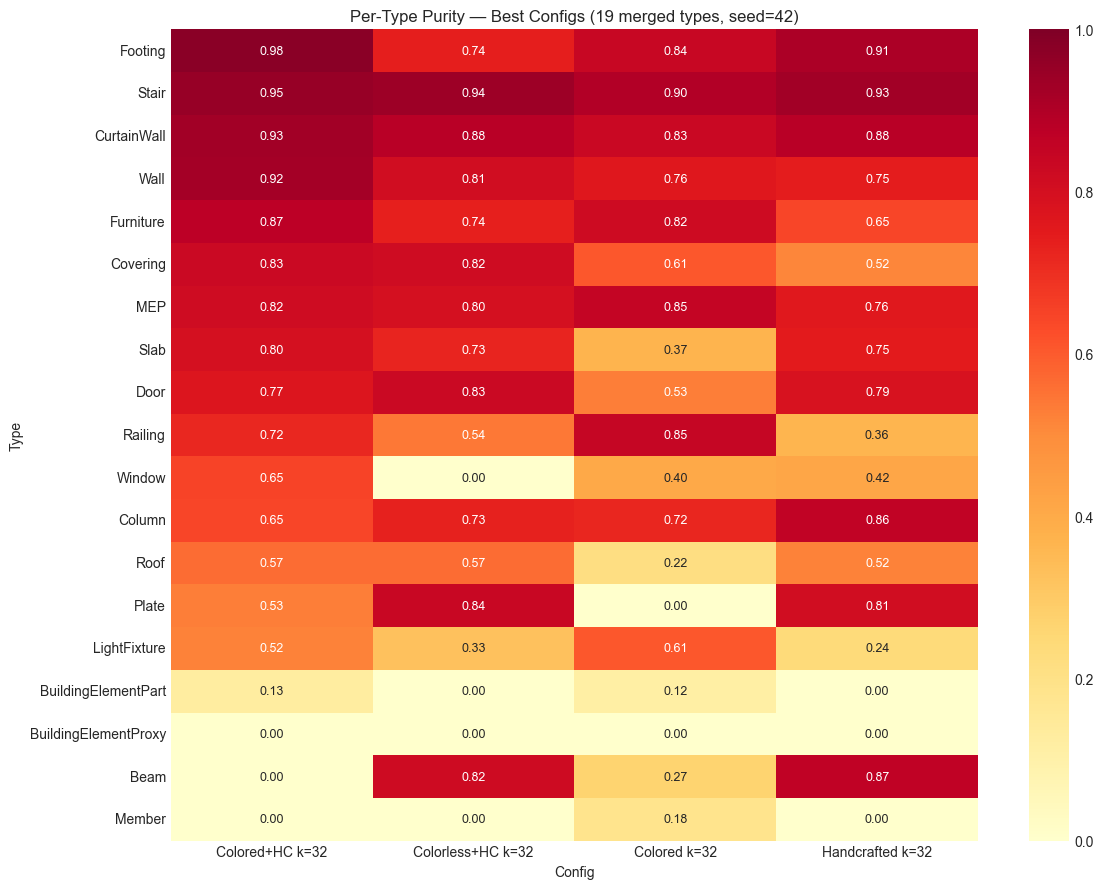

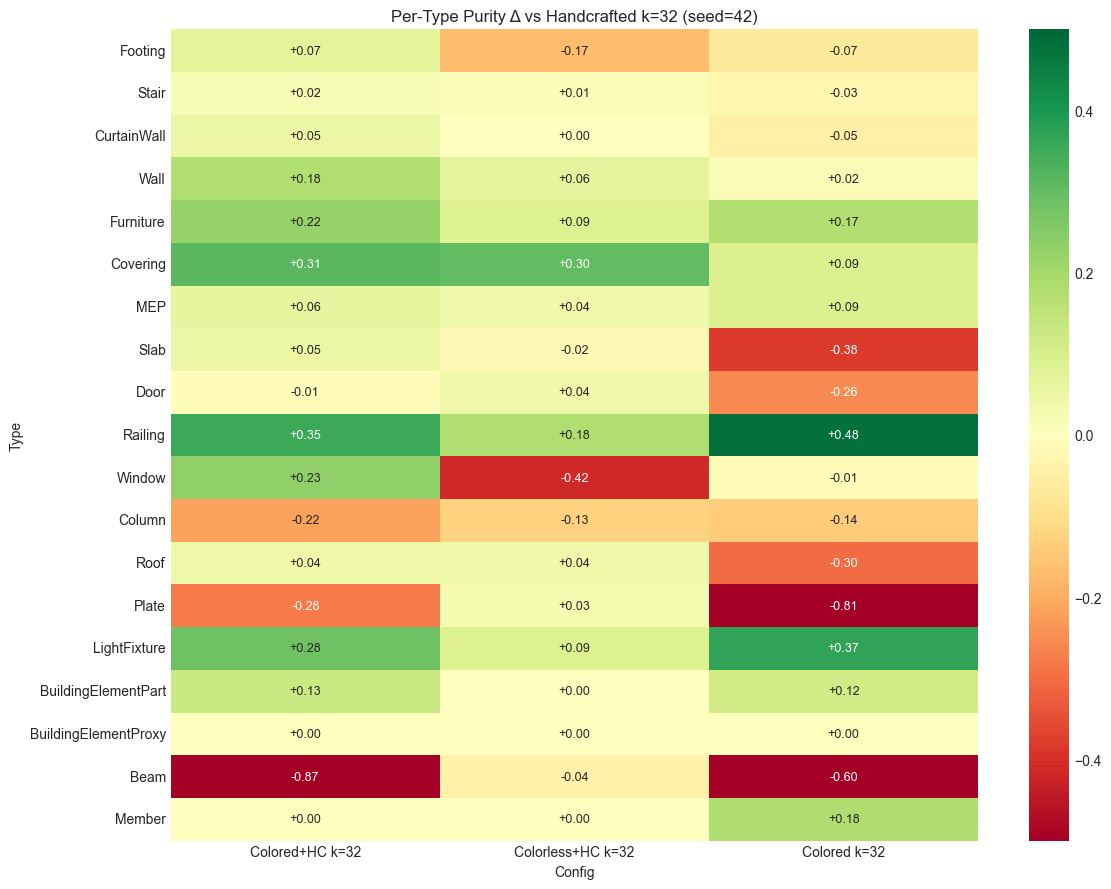

In [12]:
# Per-type purity comparison: top configs + handcrafted
all_merged = sorted(set(ifc_types))
tp_results = {}
for label, d, k, pur, X in plot_configs:
    X_sc = RobustScaler().fit_transform(X)
    lab = MiniBatchKMeans(k, batch_size=1024, n_init='auto', random_state=42).fit_predict(X_sc)
    tp_results[f'{label} k={k}'] = per_type_purity(lab, ifc_types)

tp_names = list(tp_results.keys())
df_tp = pd.DataFrame({n: [tp_results[n].get(t, 0) for t in all_merged]
                       for n in tp_names}, index=all_merged)
df_tp.index = df_tp.index.str.replace('Ifc', '')
df_tp = df_tp.sort_values(tp_names[0], ascending=False)

# Absolute purity
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_tp, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Per-Type Purity — Best Configs (19 merged types, seed=42)', fontsize=12)
ax.set_xlabel('Config'); ax.set_ylabel('Type')
plt.tight_layout(); plt.show()

# Delta vs handcrafted
hc_col = tp_names[-1]  # Handcrafted is last
df_delta = pd.DataFrame(index=df_tp.index)
for n in tp_names[:-1]:
    df_delta[n] = df_tp[n] - df_tp[hc_col]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_delta, annot=True, fmt='+.02f', cmap='RdYlGn', vmin=-0.5, vmax=0.5,
            center=0, ax=ax, annot_kws={'size': 9})
ax.set_title(f'Per-Type Purity Δ vs {hc_col} (seed=42)', fontsize=12)
ax.set_xlabel('Config'); ax.set_ylabel('Type')
plt.tight_layout(); plt.show()